# 05 — Feature Engineering (Variables Derivadas)

**Pipeline**: lee `dataset_modelado.csv`, añade 17 features derivadas, genera `dataset_fe.csv`.
**Anterior**: `04_preprocessing.ipynb`  |  **Siguiente**: `06_feature_selection.ipynb`

**Features FE-01..FE-10** (booleanos, interacciones, dispersión):
nota_rango, riesgo_intenso, nota_sq, interact_rep_nota,
faltas_por_asig, dispersion_comp, gap_stem_ling, cobertura_comp, triple_riesgo.

**Features FE-05, FE-11..FE-17** (z-scores intra-grupo):
nota_relativa_nivel, nota_media_zscore, nota_min_zscore,
pct_aprobado_zscore, n_suspensos_zscore, ling_zscore, stem_zscore, soc_zscore.

Motivación z-scores: un 6 en Bachillerato y un 6 en Primaria tienen significados distintos.
El z-score dentro de (NivCurso × Ejercicio) hace las notas comparables entre niveles,
igual que `edad_relativa` hace la edad comparable entre grupos (NB01).
Bloques LING/STEM/SOC vienen de la taxonomía de 4 bloques de NB02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Detectar raiz TFM desde cualquier subcarpeta
_cwd = Path('.').resolve()
BASE = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent] if (p / 'data').exists()),
    _cwd.parent
)
sys.path.insert(0, str(BASE))



In [2]:
df = pd.read_csv(BASE / 'data' / 'dataset_v11_preproc.csv')
print(f'Forma dataset_modelado: {df.shape}')
print(f'Target:\n{df["categoria_target"].value_counts()}')

Forma dataset_modelado: (1205, 61)
Target:
categoria_target
buen_alumno         867
en_riesgo           213
con_dificultades    125
Name: count, dtype: int64


## 1. Calcular features de ingeniería

In [3]:
# FE-01: Rango de notas — heterogeneidad del rendimiento dentro del alumno
df['fe_nota_rango'] = df['nota_max_1ev'] - df['nota_min_1ev']

# FE-02: Riesgo intenso — >=2 suspensos en 1EV es señal fuerte
df['fe_riesgo_intenso'] = (df['n_suspensos_1ev'] >= 2).astype(int)

# FE-03: Nota media cuadrática — captura no-linealidad (caída brusca bajo 5)
df['fe_nota_media_sq'] = df['nota_media_1ev'] ** 2

# FE-04: Interacción repetidor × nota media
df['fe_interact_rep_nota'] = df['IsRepetidor'] * df['nota_media_1ev']

# FE-05: → corregida y movida a la celda siguiente (bloque z-scores).
# La versión original buscaba columnas niv_* (OHE del pipeline) que no existen
# en dataset_v11_preproc.csv, por lo que el z-score resultaba global en vez de
# por nivel educativo.

# FE-06: Faltas por asignatura — absentismo normalizado por carga lectiva
df['fe_faltas_por_asig'] = (
    df['no_justificadas_1ev_log'] /
    df['n_asignaturas_1ev'].replace(0, 1)
)

# FE-07: Dispersión competencial — inconsistencia del perfil (std entre bloques)
comp_pct_cols = [c for c in df.columns if c.startswith('pct_aprobado__')]
if comp_pct_cols:
    df['fe_dispersion_comp'] = df[comp_pct_cols].std(axis=1)
else:
    df['fe_dispersion_comp'] = 0.0

# FE-08: Gap STEM vs LING — brecha entre ciencia y comunicación lingüística
# Usa nota_media__LING (bloque CCL+CP) y nota_media__STEM tras reagrupación NB02.
if 'nota_media__STEM' in df.columns and 'nota_media__LING' in df.columns:
    df['fe_gap_stem_ling'] = df['nota_media__STEM'] - df['nota_media__LING']
else:
    df['fe_gap_stem_ling'] = 0.0

# FE-09: Cobertura competencial — qué fracción de bloques tiene datos
tiene_cols = [c for c in df.columns if c.startswith('tiene_dato__')]
if tiene_cols:
    df['fe_cobertura_comp'] = df[tiene_cols].sum(axis=1) / len(tiene_cols)
else:
    df['fe_cobertura_comp'] = 0.0

# FE-10: Triple riesgo — repetidor + tiene faltas + suspensos en 1EV
df['fe_triple_riesgo'] = (
    (df['IsRepetidor'] == 1) &
    (df['tiene_faltas_nojust'] == 1) &
    (df['n_suspensos_1ev'] > 0)
).astype(int)

fe_parcial = [c for c in df.columns if c.startswith('fe_')]
print(f'{len(fe_parcial)} features FE-01..FE-04, FE-06..FE-10 (FE-05 y z-scores en celda siguiente):')
for f in fe_parcial:
    print(f'  {f:<30}  mean={df[f].mean():7.3f}  std={df[f].std():6.3f}  nulls={df[f].isnull().sum()}')

9 features FE-01..FE-04, FE-06..FE-10 (FE-05 y z-scores en celda siguiente):
  fe_nota_rango                   mean=  3.220  std= 1.715  nulls=0
  fe_riesgo_intenso               mean=  0.239  std= 0.427  nulls=0
  fe_nota_media_sq                mean= 41.662  std=15.108  nulls=0
  fe_interact_rep_nota            mean=  0.070  std= 0.682  nulls=0
  fe_faltas_por_asig              mean=  0.046  std= 0.138  nulls=0
  fe_dispersion_comp              mean=  0.117  std= 0.179  nulls=40
  fe_gap_stem_ling                mean=  0.389  std= 1.121  nulls=109
  fe_cobertura_comp               mean=  0.769  std= 0.164  nulls=0
  fe_triple_riesgo                mean=  0.000  std= 0.000  nulls=0


In [4]:
# ── Z-scores intra-grupo ELIMINADOS POR LEAKAGE ────────────────────
# Se han eliminado las features FE-05 y FE-11 a FE-17 de este notebook
# porque al calcular la media usando todo el dataset (Train + Test)
# se generaba Data Leakage.
# Si se necesitan en el futuro, deberán calcularse dinámicamente
# como un transformador dentro del pipeline (en preprocessing_pipeline.py).

# Recalculamos la lista de features de ingeniería (solo las seguras)
fe_cols = [c for c in df.columns if c.startswith('fe_')]

print(f'{len(fe_cols)} features de ingeniería 100% seguras calculadas:')
for c in fe_cols:
    n_v = df[c].notna().sum()
    print(f'  {c:<30}  {n_v:>3} válidos')

9 features de ingeniería 100% seguras calculadas:
  fe_nota_rango                   1205 válidos
  fe_riesgo_intenso               1205 válidos
  fe_nota_media_sq                1205 válidos
  fe_interact_rep_nota            1205 válidos
  fe_faltas_por_asig              1205 válidos
  fe_dispersion_comp              1165 válidos
  fe_gap_stem_ling                1096 válidos
  fe_cobertura_comp               1205 válidos
  fe_triple_riesgo                1205 válidos


## 2. Distribución por clase target

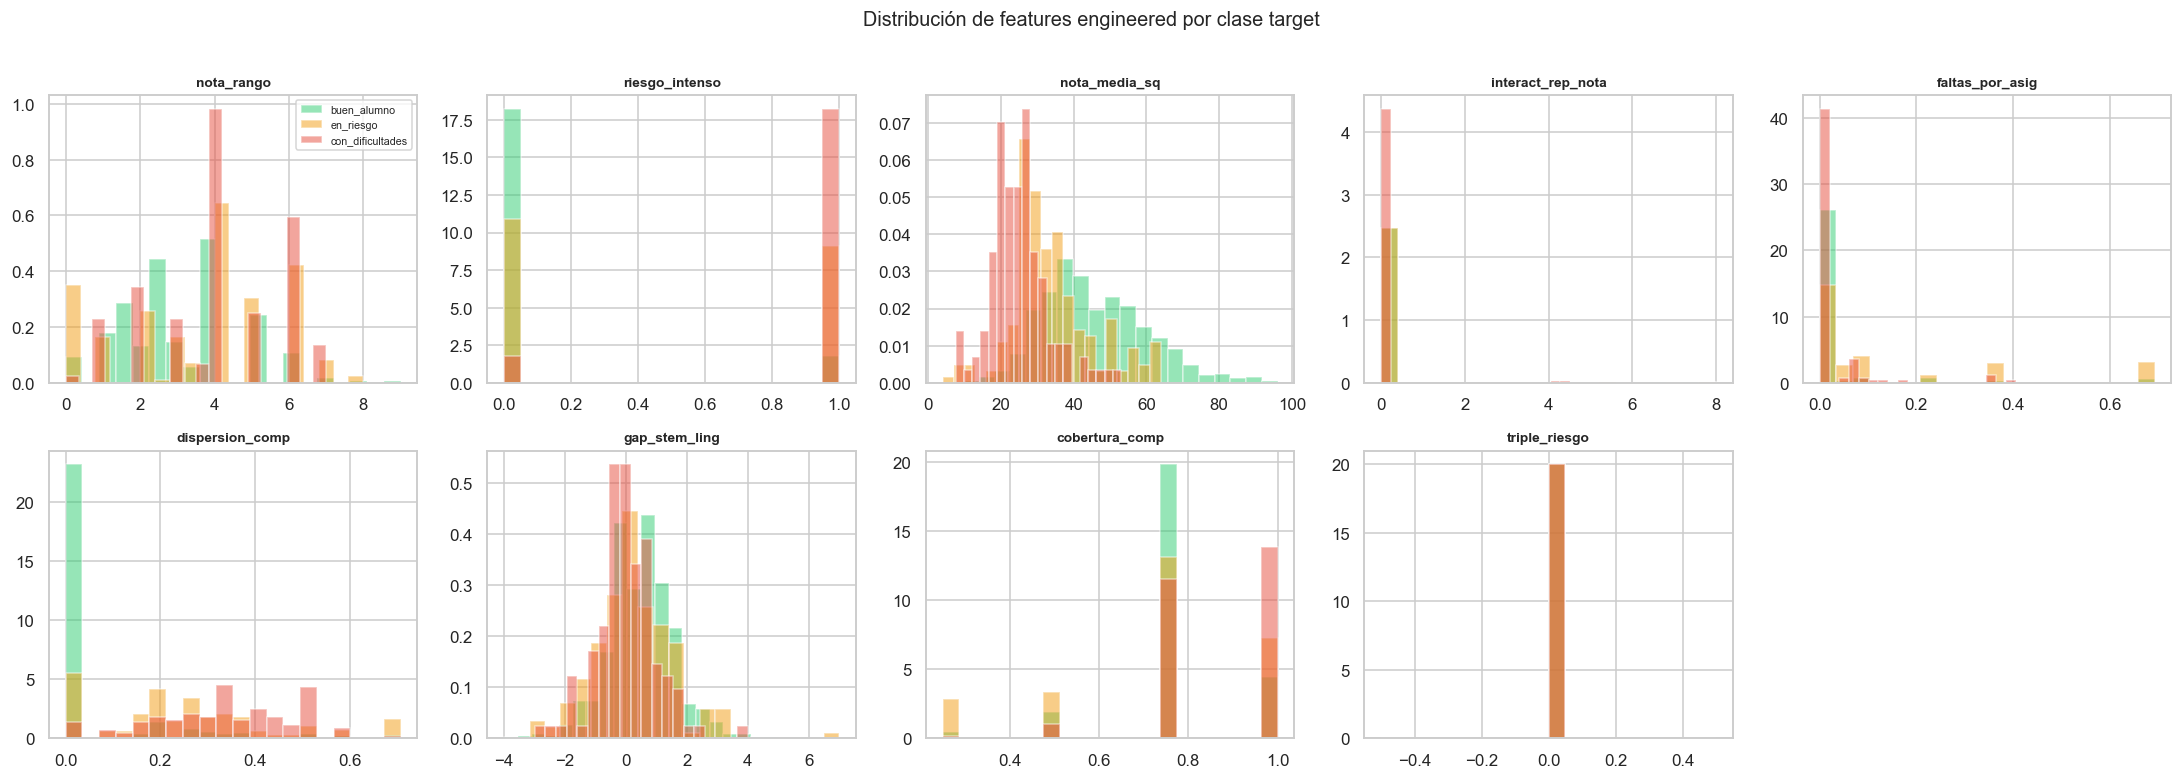

In [5]:
CAT_ORDER = ['buen_alumno', 'en_riesgo', 'con_dificultades']
COLORS    = ['#2ecc71', '#f39c12', '#e74c3c']

n_cols = 5
n_rows = int(np.ceil(len(fe_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = np.array(axes).flatten()

for i, feat in enumerate(fe_cols):
    ax = axes[i]
    for cat, color in zip(CAT_ORDER, COLORS):
        data = df.loc[df['categoria_target'] == cat, feat].dropna()
        ax.hist(data, bins=20, alpha=0.5, color=color, label=cat, density=True)
    ax.set_title(feat.replace('fe_', ''), fontsize=9, fontweight='bold')
    ax.set_xlabel('')

for ax in axes[len(fe_cols):]:
    ax.set_visible(False)

axes[0].legend(fontsize=7)
plt.suptitle('Distribución de features engineered por clase target', fontsize=13, y=1.01)
plt.tight_layout()
# fig guardada (omitido)
plt.show()

## 3. Correlación con el target

posx and posy should be finite values


posx and posy should be finite values


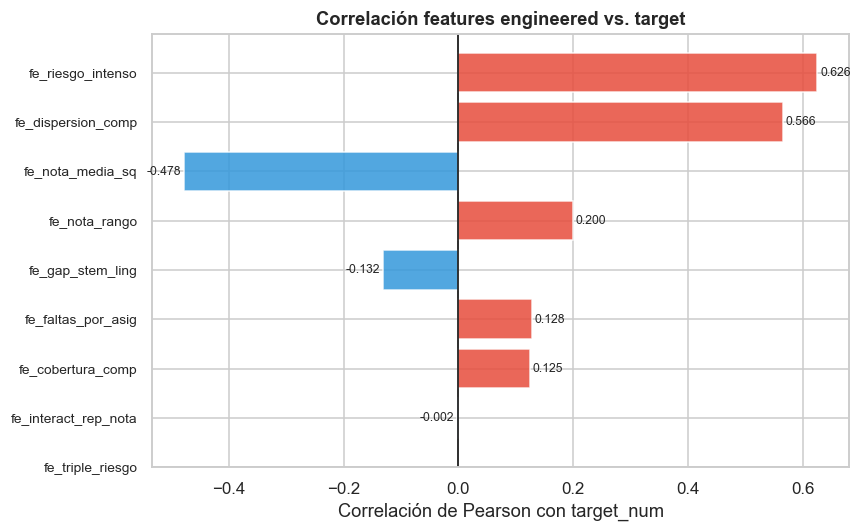


Correlaciones (ordenadas por |r|):
fe_riesgo_intenso       0.626
fe_dispersion_comp      0.566
fe_nota_media_sq       -0.478
fe_nota_rango           0.200
fe_gap_stem_ling       -0.132
fe_faltas_por_asig      0.128
fe_cobertura_comp       0.125
fe_interact_rep_nota   -0.002
fe_triple_riesgo          NaN


In [6]:
corr_fe = (
    df[fe_cols + ['target_num']]
    .corr()['target_num']
    .drop('target_num')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = ['#e74c3c' if v > 0 else '#3498db' for v in corr_fe.values]
ax.barh(range(len(corr_fe)), corr_fe.values, color=colors_corr, alpha=0.85)
ax.set_yticks(range(len(corr_fe)))
ax.set_yticklabels(corr_fe.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Correlación de Pearson con target_num')
ax.set_title('Correlación features engineered vs. target', fontweight='bold')
for i, v in enumerate(corr_fe.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i,
            f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
# fig guardada (omitido)
plt.show()

print('\nCorrelaciones (ordenadas por |r|):')
print(corr_fe.to_string())

## 4. Guardar dataset_fe.csv

In [7]:
# Verificar que no haya NaN en features engineered (excepto los que vienen del dataset base)
nulls = df[fe_cols].isnull().sum()
if nulls.any():
    print('AVISO: NaN en features FE:')
    print(nulls[nulls > 0])
    df[fe_cols] = df[fe_cols].fillna(0)
    print('  → Rellenados con 0')
else:
    print('Sin NaN en features engineered.')

out_path = BASE / 'data' / 'dataset_v11_fe.csv'
df.to_csv(out_path, index=False)
print(f'\nGuardado: {out_path}')
print(f'  Filas   : {len(df)}')
print(f'  Columnas: {df.shape[1]}  ({len(fe_cols)} nuevas + {df.shape[1] - len(fe_cols)} originales)')
print(f'  Features FE: {fe_cols}')

AVISO: NaN en features FE:
fe_dispersion_comp     40
fe_gap_stem_ling      109
dtype: int64
  → Rellenados con 0

Guardado: C:\Users\emili\OneDrive\Escritorio\TFM\data\dataset_v11_fe.csv
  Filas   : 1205
  Columnas: 70  (9 nuevas + 61 originales)
  Features FE: ['fe_nota_rango', 'fe_riesgo_intenso', 'fe_nota_media_sq', 'fe_interact_rep_nota', 'fe_faltas_por_asig', 'fe_dispersion_comp', 'fe_gap_stem_ling', 'fe_cobertura_comp', 'fe_triple_riesgo']
